# Laboratory Task 6

**Instruction:** Convert the following CNN architecture diagram into a PyTorch CNN Architecture.

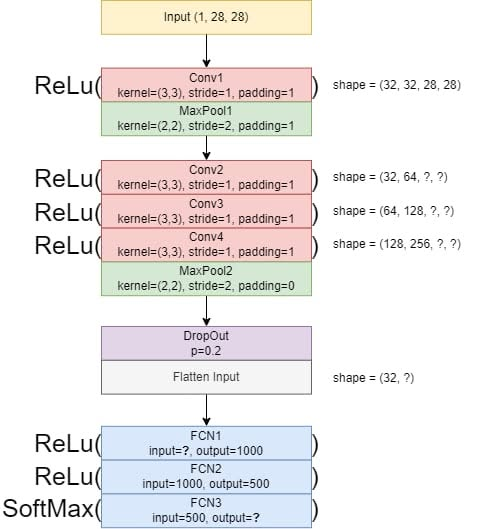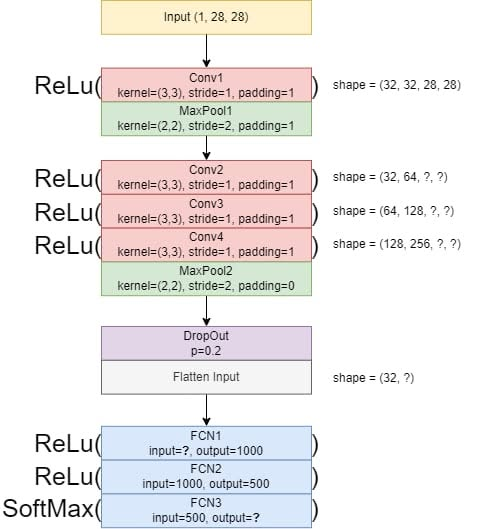

### Standart Imports

In [10]:
import torch
import torch.nn as nn

### Create the CNN Architecture

In [11]:
class CNNArchitecture(nn.Module):

    def __init__(self, num_classes=10):

        super(CNNArchitecture, self).__init__()

        # --- Block 1 ---

        # Conv1: kernel=3, stride=1, padding=1
        # Input channels=1, Output channels=32
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            stride=1,
            padding=1
        )

        self.relu = nn.ReLU()

        # MaxPool1: kernel=2, stride=2, padding=1
        self.maxpool1 = nn.MaxPool2d(
            kernel_size=2,
            stride=2,
            padding=1
        )

        # --- Block 2 ---

        # Conv2: kernel=3, stride=1, padding=1
        # Input=32, Output=64
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=1
        )

        # Conv3: kernel=3, stride=1, padding=1
        # Input=64, Output=128
        self.conv3 = nn.Conv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=3,
            stride=1,
            padding=1
        )

        # Conv4: kernel=3, stride=1, padding=1
        # Input=128, Output=256
        self.conv4 = nn.Conv2d(
            in_channels=128,
            out_channels=256,
            kernel_size=3,
            stride=1,
            padding=1
        )

        # MaxPool2: kernel=2, stride=2, padding=0
        self.maxpool2 = nn.MaxPool2d(
            kernel_size=2,
            stride=2,
            padding=0
        )

        # --- Block 3 ---

        # Dropout and Flatten
        self.dropout = nn.Dropout(p=0.2)
        self.flatten = nn.Flatten()

        # --- Block 4 ---

        # FCN1: input=12544, output=1000
        self.fc1 = nn.Linear(
            in_features=256 * 7 * 7,
            out_features=1000
        )

        # FCN2: input=1000, output=500
        self.fc2 = nn.Linear(
            in_features=1000,
            out_features=500
        )

        # FCN3: input=500, output=num_classes
        self.fc3 = nn.Linear(
            in_features=500,
            out_features=num_classes
        )

        # Softmax activation
        self.softmax = nn.Softmax(dim=1)


    def forward(self, x):

        # --- Block 1 ---
        x = self.conv1(x)
        x = self.relu(x)
        x = self.maxpool1(x)

        # --- Block 2 ---
        x = self.conv2(x)
        x = self.relu(x)

        x = self.conv3(x)
        x = self.relu(x)

        x = self.conv4(x)
        x = self.relu(x)

        x = self.maxpool2(x)

        # --- Block 3 ---
        x = self.dropout(x)
        x = self.flatten(x)

        # --- Block 4 ---
        x = self.fc1(x)
        x = self.relu(x)

        x = self.fc2(x)
        x = self.relu(x)

        x = self.fc3(x)
        x = self.softmax(x)

        return x

### Create the Model

In [12]:
model = CNNArchitecture(
    num_classes=10
)

print(model)

CNNArchitecture(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=1, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.2, inplace=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=12544, out_features=1000, bias=True)
  (fc2): Linear(in_features=1000, out_features=500, bias=True)
  (fc3): Linear(in_features=500, out_features=10, bias=True)
  (softmax): Softmax(dim=1)
)


### Create Dummy Input

In [13]:
# Dummy input tensor matching the diagram:
# (Batch Size, Channels, Height, Width)

dummy_input = torch.randn(
    32,
    1,
    28,
    28
)

print("Input shape:", dummy_input.shape)

Input shape: torch.Size([32, 1, 28, 28])


### Forward Pass

In [14]:
output = model(dummy_input)

print("Output shape:", output.shape)

Output shape: torch.Size([32, 10])


### Check the Output

In [15]:
print("Input shape:", dummy_input.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([32, 1, 28, 28])
Output shape: torch.Size([32, 10])
